In [417]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

pd.options.display.float_format = '{:.2f}'.format

In [418]:
df = pd.read_csv("dados_coletados10k.csv")

## Análise Exploratória

In [419]:
df.shape

(9517, 24)

In [420]:
df.head()

,Contrato,Idade,Sexo,Valor_Renda,UF_Cliente,Perc_Juros,Prazo_Emprestimo,Data_Contratacao,Prazo_Restante,VL_Emprestimo,VL_Emprestimo_ComJuros,QT_Total_Parcelas_Pagas,QT_Total_Parcelas_Pagas_EmDia,QT_Total_Parcelas_Pagas_EmAtraso,Qt_Renegociacao,Estado_Civil,Escolaridade,Possui_Patrimonio,VL_Patrimonio,QT_Parcelas_Atraso,QT_Dias_Atraso,Saldo_Devedor,Total_Pago,Possivel_Fraude
0,322068935715,43,M,5800.00,SP,23.00,200,2022-08-01,193,80000.00,92000.00,15,9,1,0,DIVORCIADO,Nenhum,N,0.00,0,NaN,91759.97,7717.08,Nao
1,322068936715,22,M,2000.00,MG,20.00,100,2022-08-01,89,50000.00,57500.00,10,10,0,0,SOLTEIRO(A),NaN,N,0.00,4,103.00,53981.18,6756.59,Nao
2,322068938715,35,M,4000.00,BA,18.00,100,2022-08-01,85,100000.00,115000.00,15,5,1,0,CASADO (A),NaN,N,0.00,0,NaN,101150.02,17929.06,Nao
3,322068939715,20,M,1800.00,MG,20.00,100,2022-08-01,89,30000.00,34500.00,1,1,0,0,SOLTEIRO(A),NaN,N,0.00,13,376.00,36208.10,369.10,Sim
4,322068940715,53,M,2800.00,MG,20.00,100,2022-08-01,87,60000.00,69000.00,16,16,0,0,CASADO (A),NaN,N,0.00,0,NaN,60984.00,11845.24,Nao


In [421]:
inicio = pd.to_datetime(df['Data_Contratacao']).dt.date.min()
fim = pd.to_datetime(df['Data_Contratacao']).dt.date.max()
print(inicio, fim)

2022-07-04 2022-12-20


In [422]:
df.isnull().sum()

Contrato                               0
Idade                                  0
Sexo                                   0
Valor_Renda                            0
UF_Cliente                             0
Perc_Juros                             0
Prazo_Emprestimo                       0
Data_Contratacao                       0
Prazo_Restante                         0
VL_Emprestimo                          0
VL_Emprestimo_ComJuros                 0
QT_Total_Parcelas_Pagas                0
QT_Total_Parcelas_Pagas_EmDia          0
QT_Total_Parcelas_Pagas_EmAtraso       0
Qt_Renegociacao                        0
Estado_Civil                           0
Escolaridade                        7105
Possui_Patrimonio                      0
VL_Patrimonio                          0
QT_Parcelas_Atraso                     0
QT_Dias_Atraso                      3594
Saldo_Devedor                          0
Total_Pago                             0
Possivel_Fraude                        0
dtype: int64

In [423]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9517 entries, 0 to 9516
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Contrato                          9517 non-null   int64  
 1   Idade                             9517 non-null   int64  
 2   Sexo                              9517 non-null   object 
 3   Valor_Renda                       9517 non-null   float64
 4   UF_Cliente                        9517 non-null   object 
 5   Perc_Juros                        9517 non-null   float64
 6   Prazo_Emprestimo                  9517 non-null   int64  
 7   Data_Contratacao                  9517 non-null   object 
 8   Prazo_Restante                    9517 non-null   int64  
 9   VL_Emprestimo                     9517 non-null   float64
 10  VL_Emprestimo_ComJuros            9517 non-null   float64
 11  QT_Total_Parcelas_Pagas           9517 non-null   int64  
 12  QT_Tot

In [424]:
valores_unicos = []

for i in df.columns.to_list():
    print(i, ":", len(df[i].astype(str).value_counts()))
    valores_unicos.append(len(df[i].astype(str).value_counts()))

Contrato : 9517
Idade : 74
Sexo : 2
Valor_Renda : 855
UF_Cliente : 27
Perc_Juros : 21
Prazo_Emprestimo : 36
Data_Contratacao : 110
Prazo_Restante : 79
VL_Emprestimo : 61
VL_Emprestimo_ComJuros : 61
QT_Total_Parcelas_Pagas : 24
QT_Total_Parcelas_Pagas_EmDia : 24
QT_Total_Parcelas_Pagas_EmAtraso : 15
Qt_Renegociacao : 10
Estado_Civil : 6
Escolaridade : 6
Possui_Patrimonio : 2
VL_Patrimonio : 3
QT_Parcelas_Atraso : 16
QT_Dias_Atraso : 16
Saldo_Devedor : 7654
Total_Pago : 7022
Possivel_Fraude : 2


In [425]:
df.describe()

,Contrato,Idade,Valor_Renda,Perc_Juros,Prazo_Emprestimo,Prazo_Restante,VL_Emprestimo,VL_Emprestimo_ComJuros,QT_Total_Parcelas_Pagas,QT_Total_Parcelas_Pagas_EmDia,QT_Total_Parcelas_Pagas_EmAtraso,Qt_Renegociacao,VL_Patrimonio,QT_Parcelas_Atraso,QT_Dias_Atraso,Saldo_Devedor,Total_Pago
count,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,5923.00,9517.00,9517.00
mean,322078158460.93,38.74,8325.40,19.65,107.43,104.58,81881.89,94164.17,7.89,4.11,1.60,1.24,10.93,5.35,249.79,90560.27,8166.21
std,5434160.86,12.67,121862.06,3.82,62.49,68.57,94138.06,108258.77,5.17,4.04,2.31,1.17,1025.26,5.32,123.22,111050.54,16697.76
min,322068935715.00,6.00,450.00,7.00,15.00,0.00,3500.00,4025.00,0.00,0.00,0.00,0.00,0.00,0.00,11.00,0.00,0.00
25%,322073331715.00,29.00,2300.00,18.00,60.00,51.00,20000.00,23000.00,2.00,1.00,0.00,0.00,0.00,0.00,162.00,18546.85,1202.04
50%,322078461715.00,37.00,3400.00,20.00,80.00,80.00,50000.00,57500.00,9.00,2.00,1.00,1.00,0.00,4.00,284.00,45375.30,3949.91
75%,322082622715.00,46.00,5000.00,22.00,190.00,185.00,100000.00,115000.00,13.00,6.00,2.00,2.00,0.00,11.00,344.00,119721.25,8302.01
max,322087622715.00,91.00,8000080.00,28.00,240.00,227.00,500000.00,575000.00,35.00,35.00,14.00,9.00,100000.00,15.00,435.00,625000.00,396385.00


In [426]:
df['Escolaridade'].value_counts()

Escolaridade
Nenhum                                  2184
Ensino Médio                             129
Ensino Superior                           74
Ensino Fundamental                        18
Pós Graduação / Mestrado / Doutorado       7
Name: count, dtype: int64

In [427]:
df.groupby(df['QT_Dias_Atraso']).size()

QT_Dias_Atraso
11.00     532
41.00     255
71.00     190
103.00    205
133.00    176
162.00    206
194.00    241
225.00    352
251.00    471
284.00    546
315.00    718
344.00    930
376.00    686
406.00    413
435.00      2
dtype: int64

In [428]:
df.groupby(df['Prazo_Emprestimo']).size()

Prazo_Emprestimo
15        4
18        4
19        5
20      146
25      183
30      272
34        1
35       81
36      306
40      136
42       20
45      205
48      333
50      184
55      185
60      890
65       36
70      134
75      455
80     1421
88        2
90      354
95      135
100     928
120     102
130      21
140     167
150      48
160      33
165       3
170      78
180     129
190     674
200    1661
235      71
240     110
dtype: int64

In [429]:
df.groupby(df['Sexo']).size()

Sexo
F    3811
M    5706
dtype: int64

In [430]:
df.groupby(df['Idade']).size()

Idade
6       1
17      4
18      6
19    109
20    207
21    193
22    173
23    234
24    251
25    253
26    296
27    277
28    280
29    298
30    284
31    281
32    288
33    273
34    310
35    336
36    280
37    262
38    271
39    270
40    264
41    270
42    243
43    233
44    285
45    229
46    208
47    177
48    167
49    172
50    148
51    143
52    118
53    122
54    124
55    124
56     96
57     76
58     90
59     79
60     99
61     71
62     56
63     49
64     54
65     37
66     65
67     39
68     48
69     33
70     27
71     16
72     19
73     16
74     16
75      7
76     12
77      5
78      5
79      3
80      9
81      5
82      3
83      4
84      2
85      5
87      2
88      2
90      2
91      1
dtype: int64

In [431]:
df.groupby(['Possui_Patrimonio']).size()

Possui_Patrimonio
N    9452
S      65
dtype: int64

In [432]:
df.groupby(df['Possivel_Fraude']).size()

Possivel_Fraude
Nao    5035
Sim    4482
dtype: int64

In [433]:
df.groupby(df['Estado_Civil']).size()

Estado_Civil
CASADO (A)       3027
DIVORCIADO        481
OUTRO             652
SOLTEIRO(A)      5087
UNIÃO ESTAVEL     130
VIÚVO(A)          140
dtype: int64

In [434]:
df['Estado_Civil'] = df['Estado_Civil'].replace(['UNIÃO ESTAVEL'], 'CASADO (A)')

df.groupby(df['Estado_Civil']).size()

Estado_Civil
CASADO (A)     3157
DIVORCIADO      481
OUTRO           652
SOLTEIRO(A)    5087
VIÚVO(A)        140
dtype: int64

In [435]:
# Criando faixa etaria para utilizar no modelo preditivo

bins = [0, 21, 30, 40, 50, 60, 100]
labels = ['Até 21 Anos', 'De 22 até 30 Anos', 'De 31 até 40 Anos', 'De 41 até 50 Anos', 'De 51 até 60 Anos', 'Acima de 60 Anos']
df['Faixa_Etaria'] = pd.cut(df['Idade'], bins=bins, labels=labels)

df.groupby(df['Faixa_Etaria']).size()

Faixa_Etaria
Até 21 Anos           520
De 22 até 30 Anos    2346
De 31 até 40 Anos    2835
De 41 até 50 Anos    2132
De 51 até 60 Anos    1071
Acima de 60 Anos      613
dtype: int64

In [436]:
df.head()

,Contrato,Idade,Sexo,Valor_Renda,UF_Cliente,Perc_Juros,Prazo_Emprestimo,Data_Contratacao,Prazo_Restante,VL_Emprestimo,VL_Emprestimo_ComJuros,QT_Total_Parcelas_Pagas,QT_Total_Parcelas_Pagas_EmDia,QT_Total_Parcelas_Pagas_EmAtraso,Qt_Renegociacao,Estado_Civil,Escolaridade,Possui_Patrimonio,VL_Patrimonio,QT_Parcelas_Atraso,QT_Dias_Atraso,Saldo_Devedor,Total_Pago,Possivel_Fraude,Faixa_Etaria
0,322068935715,43,M,5800.00,SP,23.00,200,2022-08-01,193,80000.00,92000.00,15,9,1,0,DIVORCIADO,Nenhum,N,0.00,0,NaN,91759.97,7717.08,Nao,De 41 até 50 Anos
1,322068936715,22,M,2000.00,MG,20.00,100,2022-08-01,89,50000.00,57500.00,10,10,0,0,SOLTEIRO(A),NaN,N,0.00,4,103.00,53981.18,6756.59,Nao,De 22 até 30 Anos
2,322068938715,35,M,4000.00,BA,18.00,100,2022-08-01,85,100000.00,115000.00,15,5,1,0,CASADO (A),NaN,N,0.00,0,NaN,101150.02,17929.06,Nao,De 31 até 40 Anos
3,322068939715,20,M,1800.00,MG,20.00,100,2022-08-01,89,30000.00,34500.00,1,1,0,0,SOLTEIRO(A),NaN,N,0.00,13,376.00,36208.10,369.10,Sim,Até 21 Anos
4,322068940715,53,M,2800.00,MG,20.00,100,2022-08-01,87,60000.00,69000.00,16,16,0,0,CASADO (A),NaN,N,0.00,0,NaN,60984.00,11845.24,Nao,De 51 até 60 Anos


In [437]:
# Faixa salarial para o modelo preditivo
bins = [-100, 1000, 2000, 3000, 5000, 10000, 20000] # -100 para considerar o 0!
labels = ['Até 1k', 'De 1k até 2k', 'De 2k até 3k', 'De 3k até 5k', 'De 5k até 10k', 'Acima de 20k']

df['Faixa_Salarial'] = pd.cut(df['Valor_Renda'], bins=bins, labels=labels)
df.groupby(['Faixa_Salarial']).size()

Faixa_Salarial
Até 1k             19
De 1k até 2k     2012
De 2k até 3k     2522
De 3k até 5k     2646
De 5k até 10k    1574
Acima de 20k      488
dtype: int64

In [438]:
# Substituindo valores nulos pela mediana dos dados
df['QT_Dias_Atraso'].median()

284.0

In [439]:
df['QT_Dias_Atraso'] = df['QT_Dias_Atraso'].fillna(df['QT_Dias_Atraso'].median())

In [440]:
# Criando faixa de dias em atraso
bins = [-100, 30, 60, 90, 180, 240, 360, 500]
labels = ['Até 30 dias', 'De 31 até 60 dias', 'De 61 até 90 dias', 'De 91 até 180 dias', 'De 181 até 240 dias', 'De 241 até 360 dias', 'Acima de 360']

df['Faixa_Dias_Atraso'] = pd.cut(df['QT_Dias_Atraso'], bins=bins, labels=labels)

In [441]:
# Criando faixa de prazo de emprestimo para o modelo preditivo
bins = [-100, 60, 120, 200, 720]
labels = ['Até 60 Meses', 'De 61 até 120 Meses', 'De 121 até 200 Meses', 'Acima de 200 Meses']

df['Faixa_Prazo_Emprestimo'] = pd.cut(df['Prazo_Emprestimo'], bins=bins, labels = labels)

In [442]:
# Criando faixa de prazo restante para o modelo preditivo
bins = [-100, 60, 120, 200, 500]
labels = ['Até 60 Meses', 'De 61 até 120 Meses', 'De 121 até 200 Meses', 'Acima de 200 Meses']

df['Faixa_Prazo_Restante'] = pd.cut(df['Prazo_Restante'], bins=bins, labels = labels)

## ANÁLISE GRÁFICA

<Axes: title={'center': 'Sexo'}, xlabel='Sexo'>

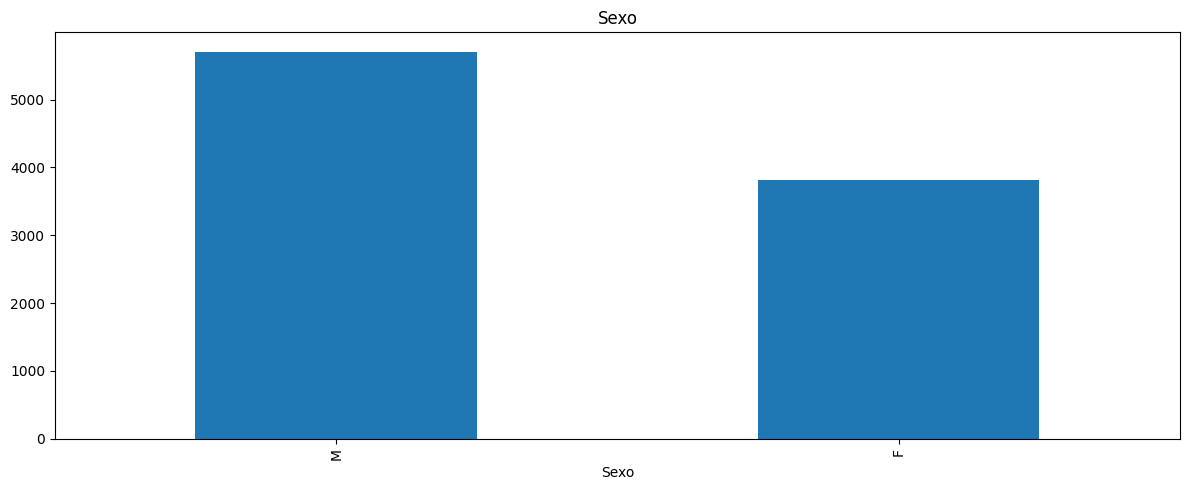

In [443]:
df.Sexo.value_counts().plot(kind='bar', title='Sexo')

<Axes: title={'center': 'UF Clientes'}, xlabel='UF_Cliente'>

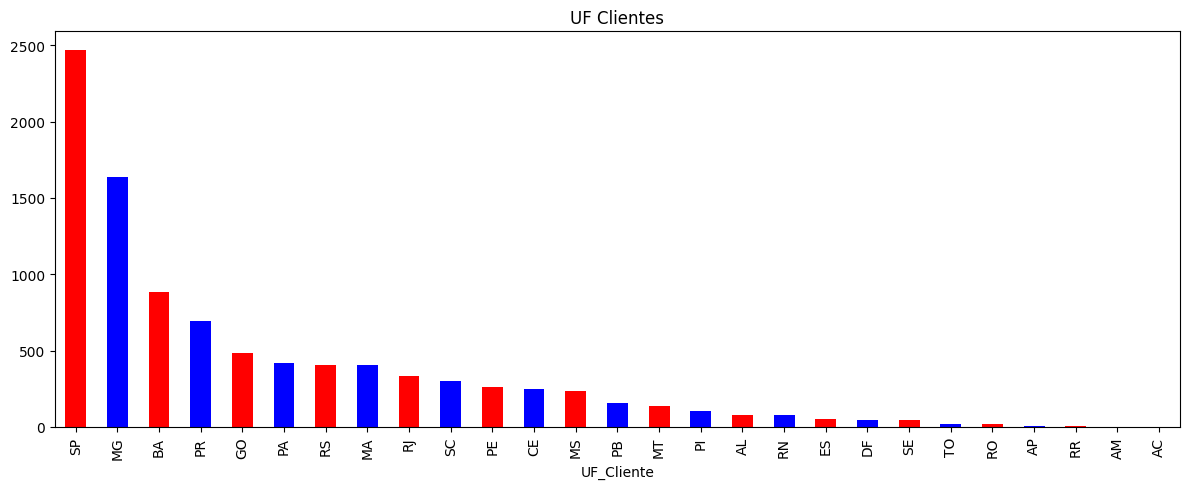

In [444]:
df.UF_Cliente.value_counts().plot(kind='bar', title='UF Clientes', color=['red','blue'])

<Axes: title={'center': 'Possível Fraude'}, xlabel='Possivel_Fraude'>

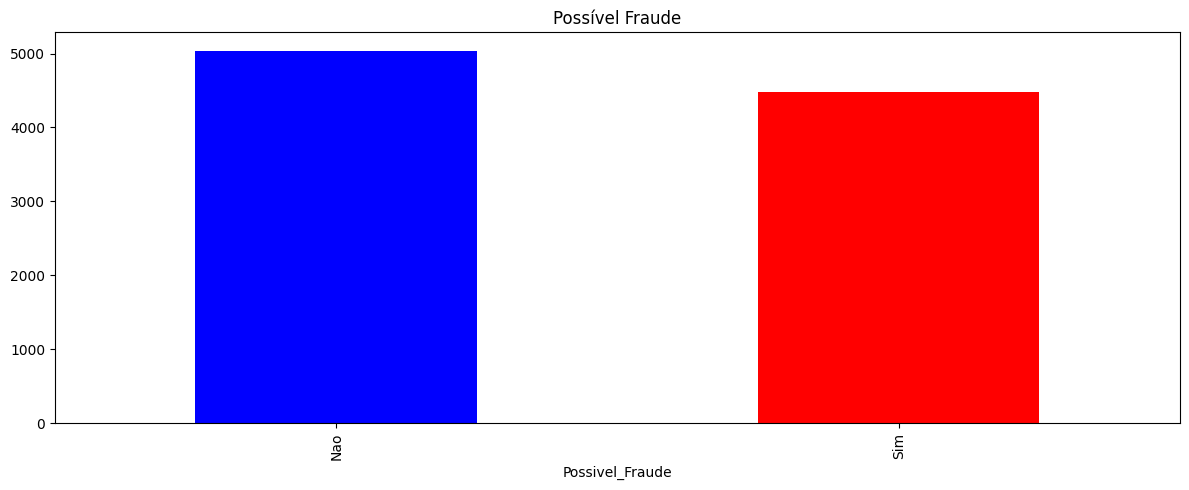

In [445]:
df.Possivel_Fraude.value_counts().plot(kind='bar', title='Possível Fraude',color=['blue', 'red'])

In [446]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9517 entries, 0 to 9516
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Contrato                          9517 non-null   int64   
 1   Idade                             9517 non-null   int64   
 2   Sexo                              9517 non-null   object  
 3   Valor_Renda                       9517 non-null   float64 
 4   UF_Cliente                        9517 non-null   object  
 5   Perc_Juros                        9517 non-null   float64 
 6   Prazo_Emprestimo                  9517 non-null   int64   
 7   Data_Contratacao                  9517 non-null   object  
 8   Prazo_Restante                    9517 non-null   int64   
 9   VL_Emprestimo                     9517 non-null   float64 
 10  VL_Emprestimo_ComJuros            9517 non-null   float64 
 11  QT_Total_Parcelas_Pagas           9517 non-null   int64 

In [447]:
df.columns

Index(['Contrato', 'Idade', 'Sexo', 'Valor_Renda', 'UF_Cliente', 'Perc_Juros',
       'Prazo_Emprestimo', 'Data_Contratacao', 'Prazo_Restante',
       'VL_Emprestimo', 'VL_Emprestimo_ComJuros', 'QT_Total_Parcelas_Pagas',
       'QT_Total_Parcelas_Pagas_EmDia', 'QT_Total_Parcelas_Pagas_EmAtraso',
       'Qt_Renegociacao', 'Estado_Civil', 'Escolaridade', 'Possui_Patrimonio',
       'VL_Patrimonio', 'QT_Parcelas_Atraso', 'QT_Dias_Atraso',
       'Saldo_Devedor', 'Total_Pago', 'Possivel_Fraude', 'Faixa_Etaria',
       'Faixa_Salarial', 'Faixa_Dias_Atraso', 'Faixa_Prazo_Emprestimo',
       'Faixa_Prazo_Restante'],
      dtype='object')

In [448]:
# COM A ANÁLISE FEITA ANTERIORMENTE PODEMOS TIRAR:
# - Contrato -> Identificação de Cliente
# - Data_Contratacao, VL_Patrimonio, Possui_Patrimonio, Escolaridade -> Não interfere no modelo
# - Idade, Valor_Renda, QT_Dias_Atraso, Prazo_Emprestimo, Prazo_Restante -> Já categorizadas em faixa

columns = ['Sexo', 'UF_Cliente', 'Perc_Juros',
       'VL_Emprestimo', 'VL_Emprestimo_ComJuros', 'QT_Total_Parcelas_Pagas',
       'QT_Total_Parcelas_Pagas_EmDia', 'QT_Total_Parcelas_Pagas_EmAtraso',
       'Qt_Renegociacao', 'Estado_Civil', 
        'QT_Parcelas_Atraso', 
       'Saldo_Devedor', 'Total_Pago', 'Possivel_Fraude', 'Faixa_Etaria',
       'Faixa_Salarial', 'Faixa_Dias_Atraso', 'Faixa_Prazo_Emprestimo',
       'Faixa_Prazo_Restante']

dados = pd.DataFrame(df, columns=columns)

In [449]:
dados.shape

(9517, 19)

In [450]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9517 entries, 0 to 9516
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Sexo                              9517 non-null   object  
 1   UF_Cliente                        9517 non-null   object  
 2   Perc_Juros                        9517 non-null   float64 
 3   VL_Emprestimo                     9517 non-null   float64 
 4   VL_Emprestimo_ComJuros            9517 non-null   float64 
 5   QT_Total_Parcelas_Pagas           9517 non-null   int64   
 6   QT_Total_Parcelas_Pagas_EmDia     9517 non-null   int64   
 7   QT_Total_Parcelas_Pagas_EmAtraso  9517 non-null   int64   
 8   Qt_Renegociacao                   9517 non-null   int64   
 9   Estado_Civil                      9517 non-null   object  
 10  QT_Parcelas_Atraso                9517 non-null   int64   
 11  Saldo_Devedor                     9517 non-null   float6

## ANÁLISE VARIÁVEIS CATEGÓRICAS

In [451]:
plt.rcParams["figure.figsize"] = [10.00, 4.00]
plt.rcParams["figure.autolayout"] = True

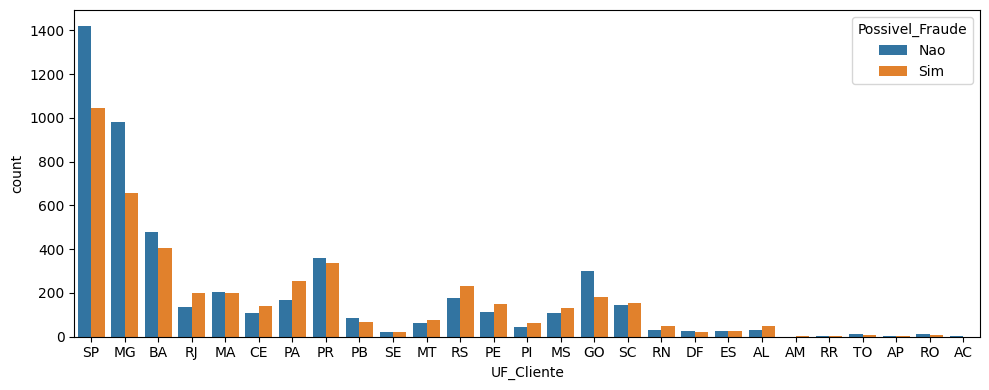

In [452]:
sns.countplot(data=dados, x="UF_Cliente", hue="Possivel_Fraude")
plt.show()

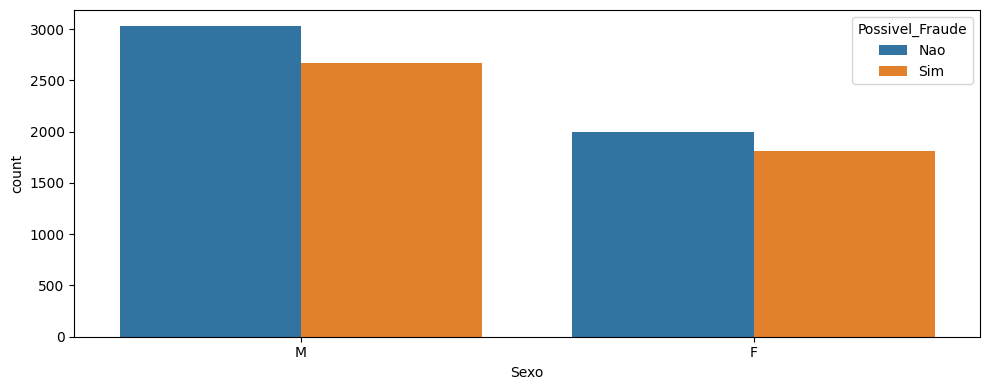

In [453]:
sns.countplot(data=dados, x="Sexo", hue="Possivel_Fraude")
plt.show()

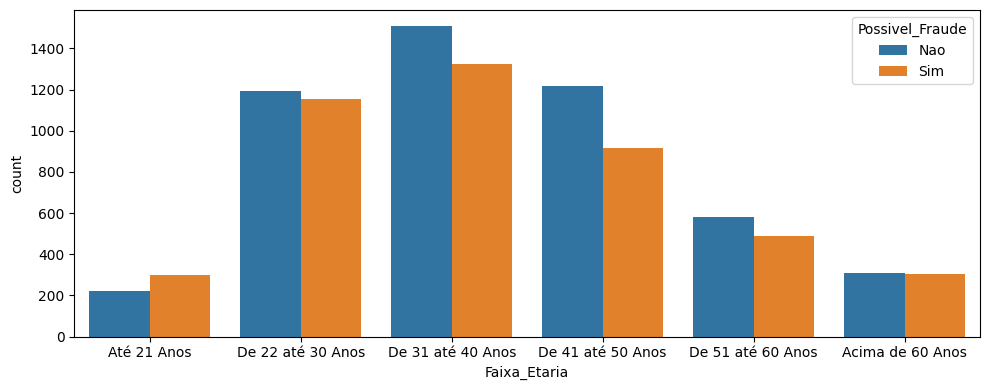

In [454]:
sns.countplot(data=dados,x="Faixa_Etaria", hue="Possivel_Fraude")
plt.show()

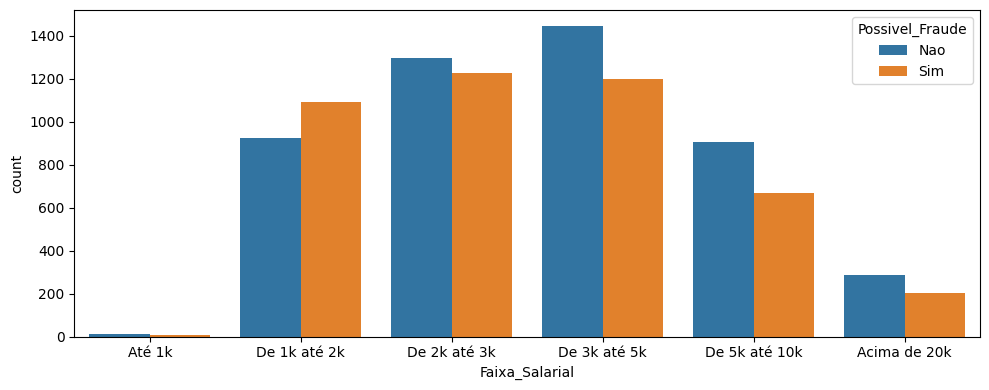

In [455]:
sns.countplot(data=dados, x="Faixa_Salarial", hue="Possivel_Fraude")
plt.show()

## ANÁLISE VARIÁVEIS NUMÉRICAS

In [456]:
variaveis_numericas = []

for i in dados.columns.tolist():
    if dados.dtypes[i] == 'int64' or dados.dtypes[i] == 'float64':
        variaveis_numericas.append(i)

variaveis_numericas

['Perc_Juros',
 'VL_Emprestimo',
 'VL_Emprestimo_ComJuros',
 'QT_Total_Parcelas_Pagas',
 'QT_Total_Parcelas_Pagas_EmDia',
 'QT_Total_Parcelas_Pagas_EmAtraso',
 'Qt_Renegociacao',
 'QT_Parcelas_Atraso',
 'Saldo_Devedor',
 'Total_Pago']

In [457]:
len(variaveis_numericas)

10

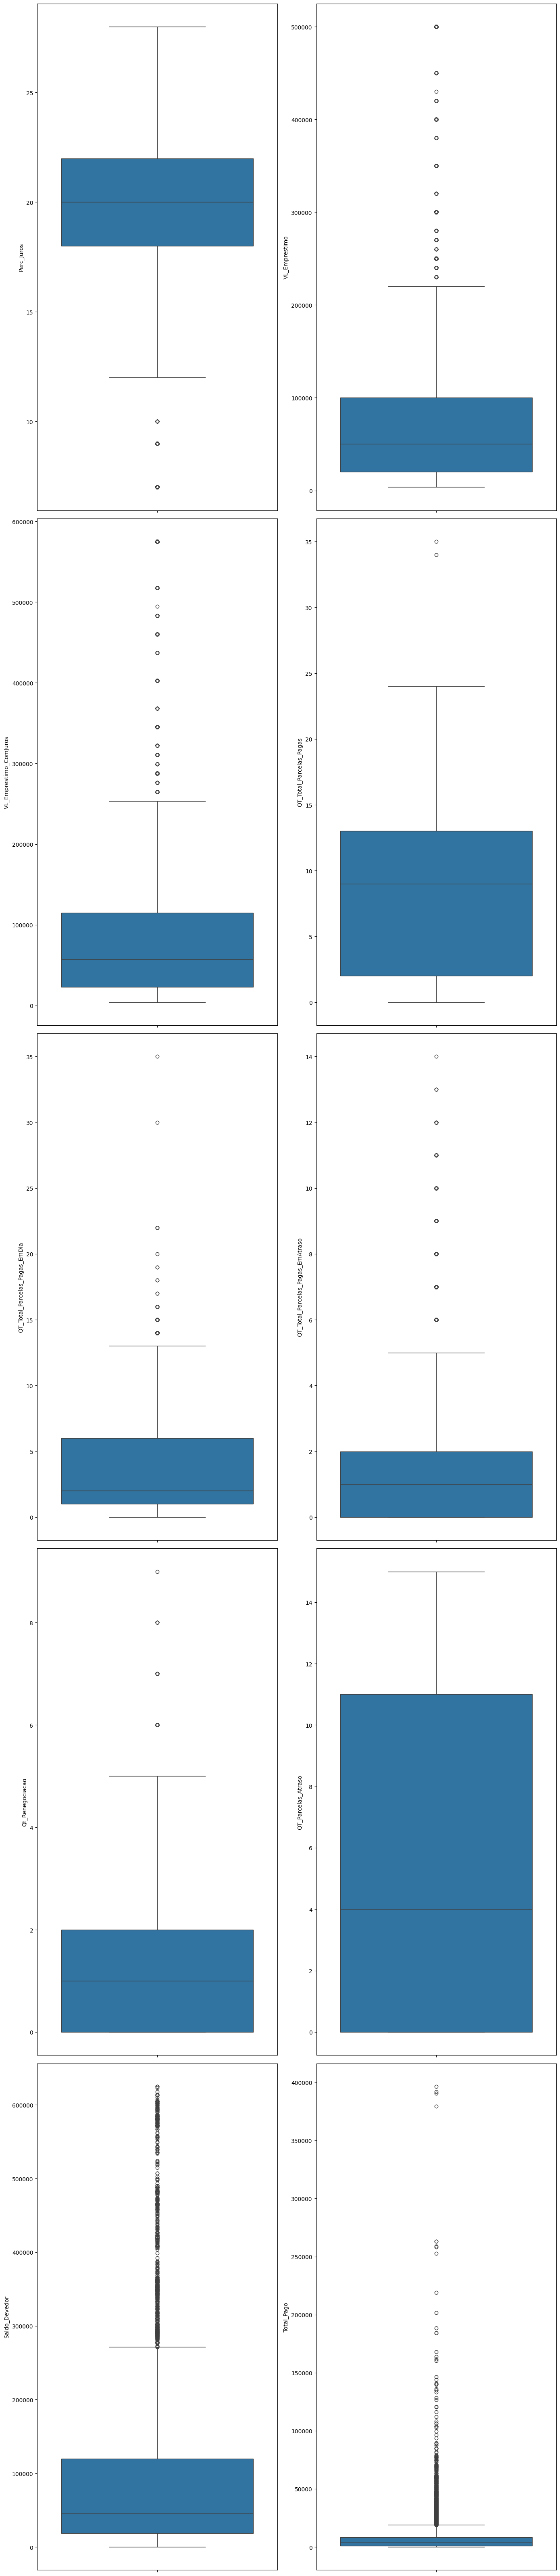

In [458]:
plt.rcParams["figure.figsize"] = [14.00, 64.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(5,2)

linha = 0
coluna = 0
for i in variaveis_numericas:
    sns.boxplot(data=dados, y=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0

plt.show()

## ONEHOTENCONDING

In [459]:
var_categoricas = []

for i in dados.columns.tolist():
    if dados.dtypes[i] == 'object' or dados.dtypes[i] == 'category':
        var_categoricas.append(i)

var_categoricas.remove('Possivel_Fraude')

In [460]:
lb = LabelEncoder()

for var in var_categoricas:
    dados[var] = lb.fit_transform(dados[var])

In [461]:
dados.isnull().sum()

Sexo                                0
UF_Cliente                          0
Perc_Juros                          0
VL_Emprestimo                       0
VL_Emprestimo_ComJuros              0
QT_Total_Parcelas_Pagas             0
QT_Total_Parcelas_Pagas_EmDia       0
QT_Total_Parcelas_Pagas_EmAtraso    0
Qt_Renegociacao                     0
Estado_Civil                        0
QT_Parcelas_Atraso                  0
Saldo_Devedor                       0
Total_Pago                          0
Possivel_Fraude                     0
Faixa_Etaria                        0
Faixa_Salarial                      0
Faixa_Dias_Atraso                   0
Faixa_Prazo_Emprestimo              0
Faixa_Prazo_Restante                0
dtype: int64

In [462]:
dados.head()

,Sexo,UF_Cliente,Perc_Juros,VL_Emprestimo,VL_Emprestimo_ComJuros,QT_Total_Parcelas_Pagas,QT_Total_Parcelas_Pagas_EmDia,QT_Total_Parcelas_Pagas_EmAtraso,Qt_Renegociacao,Estado_Civil,QT_Parcelas_Atraso,Saldo_Devedor,Total_Pago,Possivel_Fraude,Faixa_Etaria,Faixa_Salarial,Faixa_Dias_Atraso,Faixa_Prazo_Emprestimo,Faixa_Prazo_Restante
0,1,25,23.00,80000.00,92000.00,15,9,1,0,1,0,91759.97,7717.08,Nao,4,5,3,2,2
1,1,10,20.00,50000.00,57500.00,10,10,0,0,3,4,53981.18,6756.59,Nao,2,2,6,3,3
2,1,4,18.00,100000.00,115000.00,15,5,1,0,0,0,101150.02,17929.06,Nao,3,4,3,3,3
3,1,10,20.00,30000.00,34500.00,1,1,0,0,3,13,36208.10,369.10,Sim,1,2,0,3,3
4,1,10,20.00,60000.00,69000.00,16,16,0,0,0,0,60984.00,11845.24,Nao,5,3,3,3,3


In [463]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9517 entries, 0 to 9516
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Sexo                              9517 non-null   int32  
 1   UF_Cliente                        9517 non-null   int32  
 2   Perc_Juros                        9517 non-null   float64
 3   VL_Emprestimo                     9517 non-null   float64
 4   VL_Emprestimo_ComJuros            9517 non-null   float64
 5   QT_Total_Parcelas_Pagas           9517 non-null   int64  
 6   QT_Total_Parcelas_Pagas_EmDia     9517 non-null   int64  
 7   QT_Total_Parcelas_Pagas_EmAtraso  9517 non-null   int64  
 8   Qt_Renegociacao                   9517 non-null   int64  
 9   Estado_Civil                      9517 non-null   int32  
 10  QT_Parcelas_Atraso                9517 non-null   int64  
 11  Saldo_Devedor                     9517 non-null   float64
 12  Total_

In [464]:
var_target = dados.Possivel_Fraude.value_counts()
var_target

Possivel_Fraude
Nao    5035
Sim    4482
Name: count, dtype: int64

In [465]:
PREDITORAS = dados.copy()
PREDITORAS = PREDITORAS.drop(columns="Possivel_Fraude")

TARGET = dados['Possivel_Fraude']

In [466]:
PREDITORAS.head()

,Sexo,UF_Cliente,Perc_Juros,VL_Emprestimo,VL_Emprestimo_ComJuros,QT_Total_Parcelas_Pagas,QT_Total_Parcelas_Pagas_EmDia,QT_Total_Parcelas_Pagas_EmAtraso,Qt_Renegociacao,Estado_Civil,QT_Parcelas_Atraso,Saldo_Devedor,Total_Pago,Faixa_Etaria,Faixa_Salarial,Faixa_Dias_Atraso,Faixa_Prazo_Emprestimo,Faixa_Prazo_Restante
0,1,25,23.00,80000.00,92000.00,15,9,1,0,1,0,91759.97,7717.08,4,5,3,2,2
1,1,10,20.00,50000.00,57500.00,10,10,0,0,3,4,53981.18,6756.59,2,2,6,3,3
2,1,4,18.00,100000.00,115000.00,15,5,1,0,0,0,101150.02,17929.06,3,4,3,3,3
3,1,10,20.00,30000.00,34500.00,1,1,0,0,3,13,36208.10,369.10,1,2,0,3,3
4,1,10,20.00,60000.00,69000.00,16,16,0,0,0,0,60984.00,11845.24,5,3,3,3,3


In [467]:
TARGET.head()

0    Nao
1    Nao
2    Nao
3    Sim
4    Nao
Name: Possivel_Fraude, dtype: object

In [468]:
# Balanceamento
seed = 100

bal = SMOTE(random_state=seed)
PREDITORAS_RES, TARGET_RES = bal.fit_resample(PREDITORAS, TARGET)

<Axes: title={'center': 'PREDITORAS x TARGET'}, xlabel='Possivel_Fraude'>

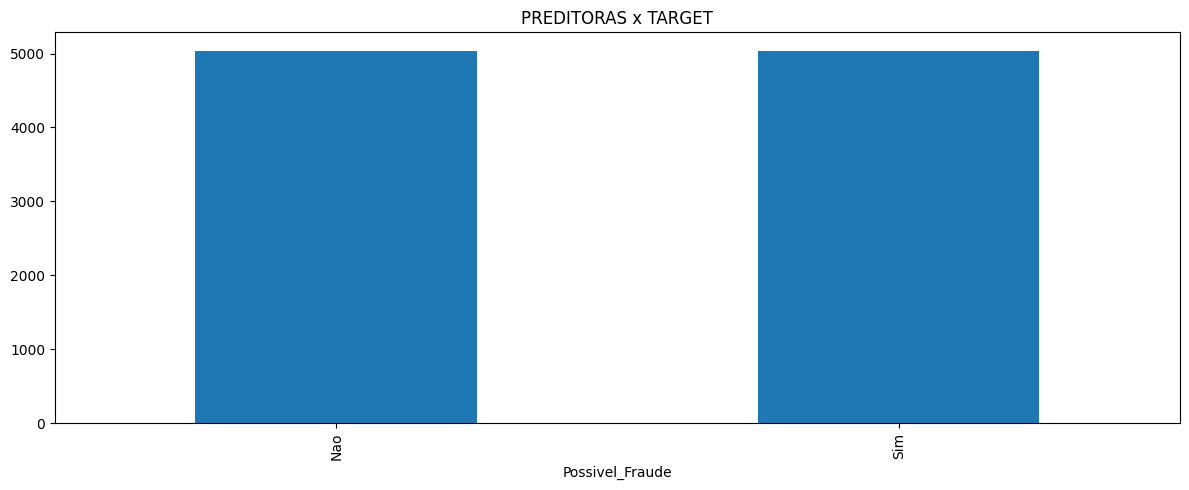

In [469]:
plt.rcParams["figure.figsize"] = [12.00, 5.00]
plt.rcParams["figure.autolayout"] = True
TARGET_RES.value_counts().plot(kind='bar', title="PREDITORAS x TARGET")

In [470]:
PREDITORAS.shape

(9517, 18)

In [471]:
TARGET.shape

(9517,)

In [472]:
PREDITORAS_RES.shape

(10070, 18)

In [473]:
TARGET_RES.shape

(10070,)

## NORMALIZAÇÃO

In [474]:
X_treino, X_teste, Y_treino, Y_teste = train_test_split(PREDITORAS_RES, TARGET_RES, test_size=0.3, random_state=42)

In [475]:
X_treino.shape

(7049, 18)

In [476]:
Normalizador = MinMaxScaler()
X_treino_normal = Normalizador.fit_transform(X_treino)
X_teste_normal = Normalizador.transform(X_teste)

In [477]:
X_treino_normal.shape

(7049, 18)

In [478]:
X_treino_normal

array([[0.        , 0.65384615, 0.57142857, ..., 0.5       , 0.66666667,
        0.        ],
       [0.        , 0.96153846, 0.61904762, ..., 0.33333333, 0.66666667,
        0.        ],
       [0.        , 0.15384615, 1.        , ..., 0.        , 0.33333333,
        0.33333333],
       ...,
       [1.        , 0.96153846, 0.71428571, ..., 0.5       , 0.66666667,
        0.66666667],
       [1.        , 0.88461538, 0.57142857, ..., 1.        , 0.66666667,
        0.66666667],
       [1.        , 0.96153846, 0.85714286, ..., 0.5       , 1.        ,
        1.        ]])

## MODELOS DE ML

In [479]:
randomForest = RandomForestClassifier()

In [480]:
n_estimators = np.array([100,200,300])
max_depth = np.array([10,20])
criterion = np.array(["gini","entropy"])
max_features = np.array(["sqrt", "log2", None])
min_samples_split = np.array([1,2,5])
min_samples_leaf = np.array([1,2,3])

grid_parametros = dict(n_estimators=n_estimators,
                       max_depth=max_depth,
                       criterion=criterion,
                       max_features=max_features,
                       min_samples_split=min_samples_split,
                       min_samples_leaf=min_samples_leaf)

randomForest = GridSearchCV(randomForest, grid_parametros, cv=3, n_jobs=6)

inicio=time.time()
randomForest.fit(X_treino_normal, Y_treino)
fim=time.time()

treinos_rf= pd.DataFrame(randomForest.cv_results_)

print(f"acuracia: {randomForest.best_score_:.2%}\n")
print(f"hiperparametros ideais: {randomForest.best_params_}\n")
print(f"tempo: {round(fim-inicio,2)}\n")
print(f"num_treinos: {treinos_rf.shape[0]}")


acuracia: 99.28%

hiperparametros ideais: {'criterion': 'entropy', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

tempo: 172.92

num_treinos: 324


In [481]:
clf = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=20, max_features='log2', min_samples_leaf=1, min_samples_split=5)

clf = clf.fit(X_treino_normal, Y_treino)

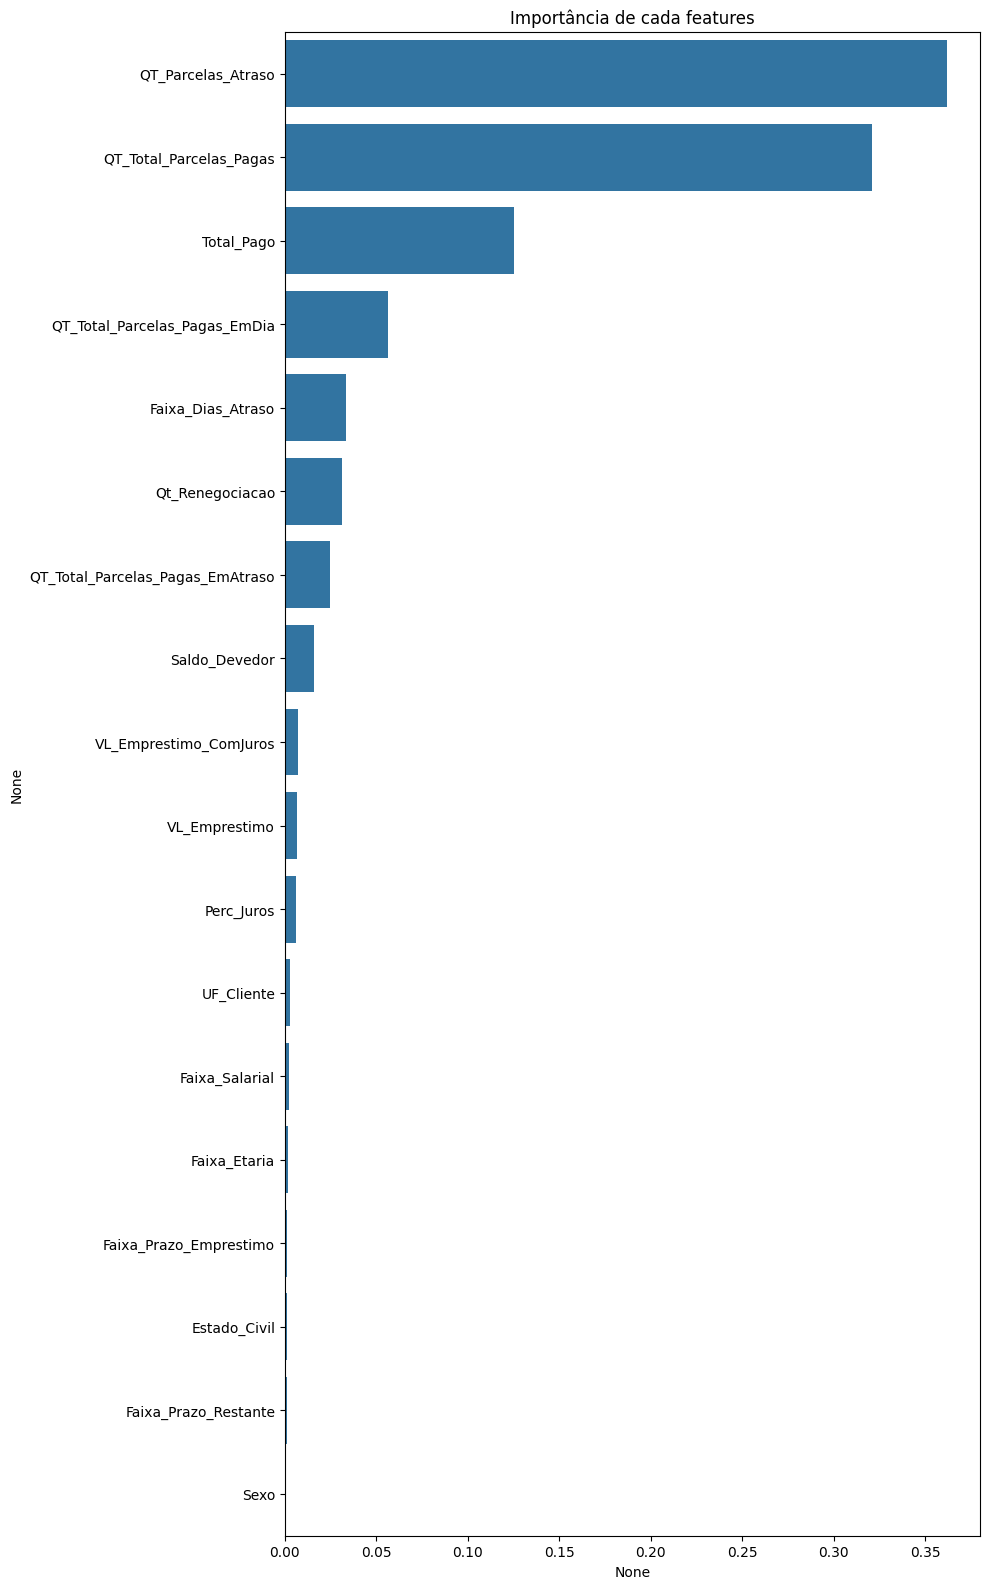

In [482]:
plt.rcParams["figure.figsize"] = [10.0,16.0]
plt.rcParams["figure.autolayout"] = True

importances = pd.Series(data=clf.feature_importances_, index=PREDITORAS.columns)
importances = importances.sort_values(ascending=False)
sns.barplot(x=importances, y=importances.index, orient='h').set_title('Importância de cada features')
plt.show()

In [483]:
scores = clf.score(X_treino_normal, Y_treino)
scores

0.999432543623209

In [484]:
scores = clf.score(X_teste_normal, Y_teste)
scores

0.9897384971863621

In [485]:
modelo_rf = {'Melhores Hiperparametros': randomForest.best_params_,
            'Numeros de Modelos treinados': treinos_rf.shape[0],
             'Melhor Score': str(round(randomForest.best_score_ * 100, 2)) +"%"
             }

In [486]:
# SVC

modelo_svm = SVC()
modelo_svm.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}